In [261]:
import pandas as pd
loans = pd.read_csv("loan_data.csv")

#loans[loans.isnull().any(axis=1)]
loans.replace("Approved", 1, inplace=True) #set these word value to numeric values
loans.replace("Rejected", 0, inplace=True)
loans.replace("employed", 1, inplace=True)
loans.replace("unemployed", 0, inplace=True)
loans.corr(numeric_only="true")["Approval"]

C:\Users\C2SDK\AppData\Local\Temp\ipykernel_22996\1552635159.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loans.replace("Rejected", 0, inplace=True)
C:\Users\C2SDK\AppData\Local\Temp\ipykernel_22996\1552635159.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loans.replace("unemployed", 0, inplace=True)


Income               0.135574
Credit_Score         0.351693
Loan_Amount         -0.085467
DTI_Ratio           -0.172182
Employment_Status    0.442970
Approval             1.000000
Name: Approval, dtype: float64

<Axes: ylabel='Frequency'>

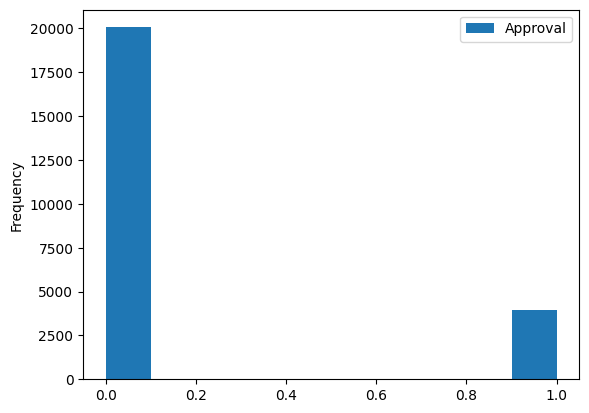

In [262]:
loans.plot.hist(y="Approval")

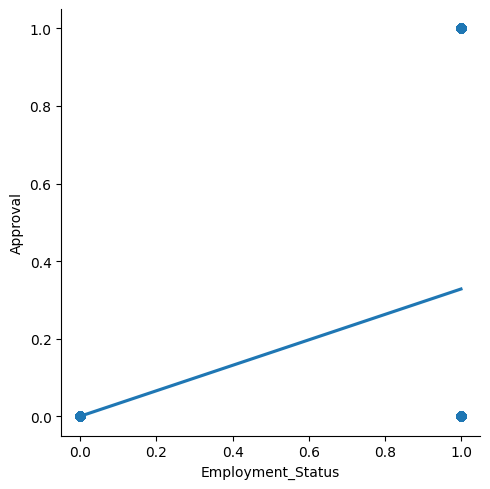

In [263]:
import seaborn as sns
sns.lmplot(x="Employment_Status", y="Approval", data=loans, fit_reg=True, ci=None)

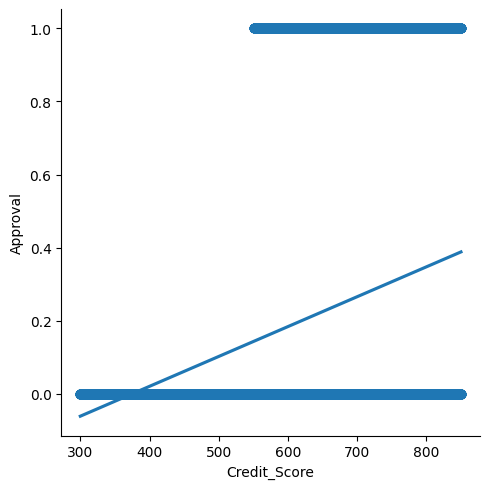

In [264]:
sns.lmplot(x="Credit_Score", y="Approval", data=loans, fit_reg=True, ci=None)

In [265]:
train=loans[loans["Loan_Amount"] < 70000].copy()
test=loans[loans["Loan_Amount"] >= 70000].copy()



In [266]:
train.shape

(18626, 7)

In [267]:
test.shape

(5374, 7)

In [268]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

#predictors = ["Employment_Status", "Credit_Score", "DTI_Ratio"]

predictors = ["Employment_Status", "Credit_Score"]
target = "Aproval"

reg.fit(train[predictors], train["Approval"])

LinearRegression()

In [269]:
predictions = reg.predict(test[predictors])
test["predictions"] = predictions
test

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval,predictions
1,I want to make home improvements like installi...,197392,389,111604,22.14,1,0,0.194698
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,0,0,0.137464
12,I want to start a small roadside food stall an...,119471,576,91198,39.29,1,0,0.363178
16,I need money to pay for a vocational training ...,167159,569,113311,25.91,0,0,-0.006690
20,I want to consolidate my credit card debts int...,198332,417,141763,25.05,0,0,-0.143637
...,...,...,...,...,...,...,...,...
23989,I need funds to pay for my pilot training prog...,183823,638,104809,4.42,1,1,0.419038
23992,I want to expand my small online clothing store.,168466,307,100946,8.35,0,0,-0.242743
23993,I need funds to pay for my daughter's college ...,160132,496,100068,25.20,0,0,-0.072461
23996,I need financial assistance to launch my own Y...,150246,729,101572,9.97,1,0,0.501026


In [270]:
test.loc[test["predictions"] < 0, "predictions"] = 0
test["predictions"] = test["predictions"].round()
test

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval,predictions
1,I want to make home improvements like installi...,197392,389,111604,22.14,1,0,0.0
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,0,0,0.0
12,I want to start a small roadside food stall an...,119471,576,91198,39.29,1,0,0.0
16,I need money to pay for a vocational training ...,167159,569,113311,25.91,0,0,0.0
20,I want to consolidate my credit card debts int...,198332,417,141763,25.05,0,0,0.0
...,...,...,...,...,...,...,...,...
23989,I need funds to pay for my pilot training prog...,183823,638,104809,4.42,1,1,0.0
23992,I want to expand my small online clothing store.,168466,307,100946,8.35,0,0,0.0
23993,I need funds to pay for my daughter's college ...,160132,496,100068,25.20,0,0,0.0
23996,I need financial assistance to launch my own Y...,150246,729,101572,9.97,1,0,1.0


In [271]:
from sklearn.metrics import mean_absolute_error
error = mean_absolute_error(test["Approval"], test["predictions"])
error

0.12579084480833644

In [272]:
check = reg.predict([[0, 800], [1, 700]])
check

c:\Users\C2SDK\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([0.20143266, 0.47489793])